In [36]:
!pip install nltk
!pip install Sastrawi
!pip install emoji

In [37]:
import pandas as pd
import numpy as np
import re
import emoji
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
import nltk

In [38]:
data1 = 'tiktok 10 des (cijesfel).csv'
data2 = 'tiktok 10 des (detikcom).csv'
data3 = 'tiktok 9 des (inilahcom).csv'

df1 = pd.read_csv(data1)
df2 = pd.read_csv(data2)
df3 = pd.read_csv(data3)


In [39]:
df1.sample(5)

,user,komen,Tanggal komentar,likes
696,putrikembar,😅😅dia merasa nanti rakyat tidak sayang lagi ke...,2d ago,0.0
1491,🕊🕊🕊,NaN,3d ago,0.0
1452,07,respect sm ferry irwandi👍,3d ago,0.0
1697,Yadhink Nekara,🤣🤣🤣,3d ago,0.0
2677,taufik87,klo nunggu pemerintah lama..alhamdulillah ada ...,3d ago,0.0


In [40]:
df2.sample(5)

,user,komen,Tanggal komentar,likes
702,Suket Teki,"DPR lagi ,DPR lagiiii",3d ago,0
695,cinta,"mending lah 1 orng Bntu 1 0 m, dari PD pejbt m...",3d ago,0
153,☞..ALDO..☜,"DPR gimana mau bantu kesana ,orang biaya hotel...",3d ago,3
915,beeeen,lah ada yang beras 60k,2d ago,0
634,NengAugust 2,"gw sich, dukung yg mau bantu gercep atas musib...",3d ago,0


In [41]:
df3.sample(5)

,user,komen,Tanggal komentar,likes
25,Adanu,dari partai apa ya??\nkok statement kayak gitu...,3d ago,126
245,user55581,"kalo niatnya emng bantumah pak gausah bawa"" pu...",3d ago,7
154,acesaa,rakyat sendiri aja dianggap saingan wkwk,3d ago,12
869,Oyennn,nyumbang itu kan uang pajak ya?(bertanya denga...,1d ago,1
103,WonkngalaM,"pantes gerindra, gk ketua, gk anak buah sm aja...",3d ago,60


In [42]:
# Mengecek jumlah row & coloumn
print(f'shape data1 : {df1.shape}')
print(f'shape data2 : {df2.shape}')
print(f'shape data3 : {df3.shape}')

shape data1 : (2811, 4)
shape data2 : (1110, 4)
shape data3 : (1073, 4)


**GABUNGIN 3 DATA**

In [43]:
import pandas as pd

# Baca ketiga file
data1 = pd.read_csv('tiktok 10 des (cijesfel).csv')
data2 = pd.read_csv('tiktok 10 des (detikcom).csv')
data3 = pd.read_csv('tiktok 9 des (inilahcom).csv')


# Gabungkan secara vertikal
df_gabung = pd.concat([df1, df2, df3], ignore_index=True)

# Simpan hasil (opsional)
df_gabung.to_csv('data_gabungan.csv', index=False)

In [44]:
data_path = 'data_gabungan.csv'
df = pd.read_csv(data_path)

In [45]:
# Jika df_gabung adalah DataFrame hasil penggabungan
jumlah_baris = len(df_gabung)
# atau
jumlah_baris, jumlah_kolom = df_gabung.shape

print(f"Jumlah baris setelah digabung: {jumlah_baris}")
print(f"Jumlah kolom: {jumlah_kolom}")

Jumlah baris setelah digabung: 4994
Jumlah kolom: 4


**BERSIHKAN DATA YG MASIH BELUM RAPI (SESUAIKAN DENGAN KOMENTAR YG ADA**

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4994 entries, 0 to 4993
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   user              4976 non-null   object
 1   komen             4943 non-null   object
 2   Tanggal komentar  4976 non-null   object
 3   likes             4968 non-null   object
dtypes: object(4)
memory usage: 156.2+ KB


In [47]:
import pandas as pd

# Baca dataset (ganti nama file sesuai kebutuhan)
df = pd.read_csv('data_gabungan.csv')  # ← pastikan file ini ada!

# Cek jumlah baris sebelum
print(f"Jumlah baris SEBELUM cleaning: {len(df)}")

# Hapus baris yang NaN di kolom 'cleaned_komen'
df_clean = df.dropna(subset=['komen'])

# Hapus baris yang string kosong atau hanya spasi
df_clean = df_clean[df_clean['komen'].str.strip().astype(str) != '']

# Cek jumlah baris setelah
print(f"Jumlah baris SETELAH cleaning: {len(df_clean)}")
print(f"Jumlah baris yang dihapus: {len(df) - len(df_clean)}")

# Simpan hasil
df_clean.to_csv('data_gabungan_cleaned.csv', index=False)

# Tampilkan contoh
print("\nContoh data setelah cleaning:")
print(df_clean[['komen']].head(5))

Jumlah baris SEBELUM cleaning: 4994
Jumlah baris SETELAH cleaning: 4943
Jumlah baris yang dihapus: 51

Contoh data setelah cleaning:
                                            komen
2                     semangat bang Ferry Irwandi
3                   reaksi fery irwandi di sindir
4                                    goodd joobbb
5  1 Ferry Irwandi lebih berguna dr pada 1000 dpr
6                           ini dia orang nya😁😅😁😅


**HAPUS DUPLICATE**

In [48]:
# Cek jumlah nilai duplikat di kolom 'user'
duplicates = df['user'].duplicated(keep=False)  # semua duplikat (termasuk yang pertama)
print(f"Jumlah baris dengan nilai duplikat di 'user': {duplicates.sum()}")

# Tampilkan contoh duplikat
print("\nContoh baris dengan nilai duplikat:")
print(df[duplicates].head(10))

Jumlah baris dengan nilai duplikat di 'user': 339

Contoh baris dengan nilai duplikat:
                 user                                              komen  \
0                 NaN                                                NaN   
1                 NaN                                                NaN   
3              Taurus                      reaksi fery irwandi di sindir   
5    aceh LOEN sayang     1 Ferry Irwandi lebih berguna dr pada 1000 dpr   
10                NaN                                                NaN   
11                NaN                                                NaN   
12                NaN                                                NaN   
28          Nadirtoys  gw kalo jadi pejabat. : Trima kasih kepada Fer...   
67            ACW AIM                        gak percaya sama dpr itu...   
100              Heni        kasian .. mungkin dia iri karna nggk diajak   

    Tanggal komentar   likes  
0                NaN     NaN  
1             

In [49]:
# Baca data
df = pd.read_csv('data_gabungan_cleaned.csv')

# Hapus duplikat berdasarkan kolom 'akun' — simpan baris pertama
df_clean = df.drop_duplicates(subset=['user'], keep='first')

# Tampilkan info
print(f"Sebelum: {len(df)} baris")
print(f"Sesudah: {len(df_clean)} baris")
print(f"Jumlah duplikat dihapus: {len(df) - len(df_clean)}")

# Simpan hasil
df_clean.to_csv('cleaning duplicate instagram.csv', index=False)

Sebelum: 4943 baris
Sesudah: 4771 baris
Jumlah duplikat dihapus: 172


In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4943 entries, 0 to 4942
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   user              4943 non-null   object
 1   komen             4943 non-null   object
 2   Tanggal komentar  4943 non-null   object
 3   likes             4935 non-null   object
dtypes: object(4)
memory usage: 154.6+ KB


**PREPOCESSING DATA (HAPUS EMOJI & KECILKAN HURUF)**

In [51]:
# Fungsi untuk menghapus emoji
def remove_emoji(text):
    if isinstance(text, str):  # Check if the text is a string before processing
        return emoji.replace_emoji(text, replace='')
    else:
        return text  # Return the original value if it's not a string

# Fungsi untuk membersihkan teks
def clean_text(text):
    # Menghapus emoji
    text = remove_emoji(text)
    # Mengubah ke huruf kecil
    if isinstance(text, str):  # Check if the text is a string before processing
        text = text.lower()
        # Menghapus username, hashtag, dan link
        text = re.sub(r'@\w+|#\w+|http\S+', '', text)
        # Menghapus angka dan tanda baca kecuali huruf
        text = re.sub(r'[^a-z\s]', '', text)
        # Menghapus spasi ekstra
        text = re.sub(r'\s+', ' ', text).strip()
    return text

# Mengaplikasikan fungsi clean_text ke kolom 'comment'
df['cleaned_komen'] = df['komen'].apply(clean_text)

# Menampilkan data yang sudah dibersihkan
print("\nData Setelah Pembersihan:")
print(df.head())


Data Setelah Pembersihan:
               user                                           komen  \
0     Sri Heldawati                     semangat bang Ferry Irwandi   
1            Taurus                   reaksi fery irwandi di sindir   
2     Buchex.. 1997                                    goodd joobbb   
3  aceh LOEN sayang  1 Ferry Irwandi lebih berguna dr pada 1000 dpr   
4              Azka                           ini dia orang nya😁😅😁😅   

  Tanggal komentar   likes                            cleaned_komen  
0           3d ago   452.0              semangat bang ferry irwandi  
1           3d ago   355.0            reaksi fery irwandi di sindir  
2          29m ago     0.0                             goodd joobbb  
3           3d ago  2304.0  ferry irwandi lebih berguna dr pada dpr  
4           3d ago  7875.0                        ini dia orang nya  


**MENGHAPUS STOPWORDS**

In [52]:
# Mengunduh stopwords dan tokenizer
nltk.download('stopwords')
nltk.download('punkt')
import nltk
nltk.download('punkt_tab')

# Menghapus stop words
stop_words = set(stopwords.words('indonesian'))  # Gunakan stopwords bahasa Indonesia
df['cleaned_komen'] = df['cleaned_komen'].apply(
    lambda x: ' '.join([word for word in word_tokenize(x) if word not in stop_words]) if isinstance(x, str) else x
)

# Menampilkan data setelah penghapusan stop words
print("\nData Setelah Penghapusan Stop Words:")
print(df.head())

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!



Data Setelah Penghapusan Stop Words:
               user                                           komen  \
0     Sri Heldawati                     semangat bang Ferry Irwandi   
1            Taurus                   reaksi fery irwandi di sindir   
2     Buchex.. 1997                                    goodd joobbb   
3  aceh LOEN sayang  1 Ferry Irwandi lebih berguna dr pada 1000 dpr   
4              Azka                           ini dia orang nya😁😅😁😅   

  Tanggal komentar   likes                 cleaned_komen  
0           3d ago   452.0   semangat bang ferry irwandi  
1           3d ago   355.0    reaksi fery irwandi sindir  
2          29m ago     0.0                  goodd joobbb  
3           3d ago  2304.0  ferry irwandi berguna dr dpr  
4           3d ago  7875.0                     orang nya  


**STEMMING DATA**

In [18]:
# Membuat objek stemmer
factory = StemmerFactory()
stemmer = factory.create_stemmer()

# Proses stemming
df['stemmed_komen'] = df['cleaned_komen'].apply(
    lambda x: stemmer.stem(x) if isinstance(x, str) else ''
)

# Menampilkan data setelah stemming
print("\nData Setelah Stemming:")
print(df.head())


Data Setelah Stemming:
               user                                           komen  \
0     Sri Heldawati                     semangat bang Ferry Irwandi   
1            Taurus                   reaksi fery irwandi di sindir   
2     Buchex.. 1997                                    goodd joobbb   
3  aceh LOEN sayang  1 Ferry Irwandi lebih berguna dr pada 1000 dpr   
4              Azka                           ini dia orang nya😁😅😁😅   

  Tanggal komentar   likes                 cleaned_komen  \
0           3d ago   452.0   semangat bang ferry irwandi   
1           3d ago   355.0    reaksi fery irwandi sindir   
2          29m ago     0.0                  goodd joobbb   
3           3d ago  2304.0  ferry irwandi berguna dr dpr   
4           3d ago  7875.0                     orang nya   

                 stemmed_komen  
0  semangat bang ferry irwandi  
1   reaksi fery irwandi sindir  
2                 goodd joobbb  
3    ferry irwandi guna dr dpr  
4                    or

**TOKENIZATION**

In [19]:
# Tokenisasi
df['tokens'] = df['stemmed_komen'].apply(
    lambda x: word_tokenize(x) if isinstance(x, str) else []
)

# Menampilkan data setelah tokenisasi
print("\nData Setelah Tokenisasi:")
print(df.head())

# Menyimpan data yang sudah diproses ke file baru
df.to_csv('processed_clean.csv', index=False)


Data Setelah Tokenisasi:
               user                                           komen  \
0     Sri Heldawati                     semangat bang Ferry Irwandi   
1            Taurus                   reaksi fery irwandi di sindir   
2     Buchex.. 1997                                    goodd joobbb   
3  aceh LOEN sayang  1 Ferry Irwandi lebih berguna dr pada 1000 dpr   
4              Azka                           ini dia orang nya😁😅😁😅   

  Tanggal komentar   likes                 cleaned_komen  \
0           3d ago   452.0   semangat bang ferry irwandi   
1           3d ago   355.0    reaksi fery irwandi sindir   
2          29m ago     0.0                  goodd joobbb   
3           3d ago  2304.0  ferry irwandi berguna dr dpr   
4           3d ago  7875.0                     orang nya   

                 stemmed_komen                            tokens  
0  semangat bang ferry irwandi  [semangat, bang, ferry, irwandi]  
1   reaksi fery irwandi sindir   [reaksi, fery, irwa

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4943 entries, 0 to 4942
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   user              4943 non-null   object
 1   komen             4943 non-null   object
 2   Tanggal komentar  4943 non-null   object
 3   likes             4935 non-null   object
 4   cleaned_komen     4943 non-null   object
 5   stemmed_komen     4943 non-null   object
 6   tokens            4943 non-null   object
dtypes: object(7)
memory usage: 270.4+ KB


**BUAT VISUALISASI WORLDCLOUD**

In [21]:
from wordcloud import STOPWORDS

# Tambahkan kata khusus Indonesia yang mungkin tidak ada di daftar bawaan
stop_words = set(STOPWORDS)
stop_words.update(['yg', 'nya', 'dgn', 'ya', 'trs', 'jg', 'kalo', 'gw', 'lu', 'gue', 'lo', 'nih', 'mah', 'sih', 'krn', 'karena'])

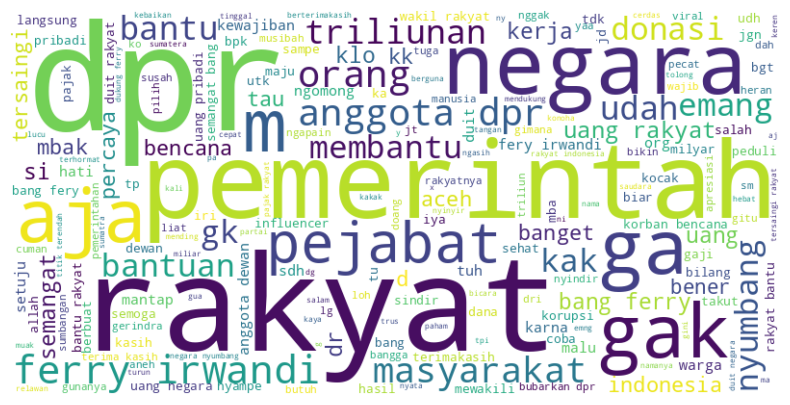

In [22]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import pandas as pd

# Memuat data dari file CSV
df = pd.read_csv('processed_clean.csv')  # Ganti 'path_to_your_file.csv' dengan jalur file data Anda

# Gabungkan semua teks dalam kolom 'cleaned_komen' menjadi satu string besar
text = " ".join(judul for judul in df['cleaned_komen'].dropna())  # Pastikan tidak ada nilai NaN



# Generate the word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white', stopwords=stop_words).generate(text)

# Display the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')  # Remove axis
plt.show()

**VISUALISASI KATA KUNCI TERBANYAK (WORDCLOUD)**

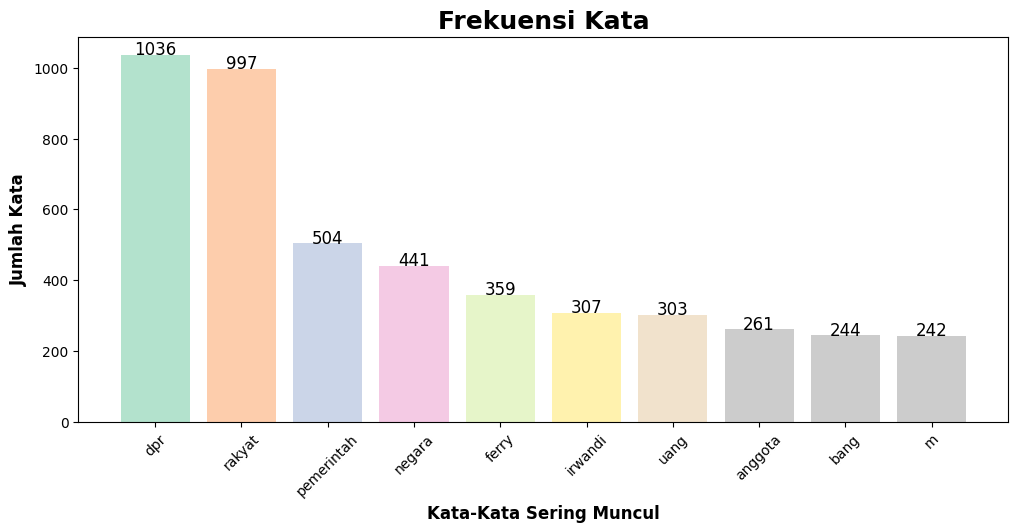

In [23]:
import matplotlib.pyplot as plt
from collections import Counter
from wordcloud import STOPWORDS

text = " ".join(judul for judul in df['cleaned_komen'].dropna())


tokens = [word for word in text.split() if word not in stop_words]
word_counts = Counter(tokens)

top_words = word_counts.most_common(10)
word, count = zip(*top_words)

# Menggunakan palet warna lebih soft
colors = plt.cm.Pastel2(range(len(word)))

# Membuat plot
plt.figure(figsize=(12, 5))
bars = plt.bar(word, count, color=colors)
plt.xlabel("Kata-Kata Sering Muncul", fontsize=12, fontweight='bold')
plt.ylabel("Jumlah Kata", fontsize=12, fontweight='bold')
plt.title("Frekuensi Kata", fontsize=18, fontweight='bold')
plt.xticks(rotation=45)

# Menambahkan angka rata tengah di atas setiap bar
for bar, num in zip(bars, count):
    plt.text(bar.get_x() + bar.get_width() / 1.6 - 0.1, num + 1, str(num), fontsize=12, color='black', ha='center')

# Menampilkan plot
plt.show()

**LABELING DATA (POSITIF, NEGATIF, NETRAL) LEXICON BASED**

In [24]:
# Unduh kamus leksikon positif dan negatif dari GITHUB
positive_url = "https://raw.githubusercontent.com/fajri91/InSet/master/positive.tsv"
negative_url = "https://raw.githubusercontent.com/fajri91/InSet/master/negative.tsv"

positive_lexicon = set(pd.read_csv(positive_url, sep='\t', header=None)[0])
negative_lexicon = set(pd.read_csv(negative_url, sep='\t', header=None)[0])

# Fungsi untuk menentukan sentimen dan menghitung skornya
def determine_sentiment(text):
    if isinstance(text, str):
        positive_count = sum(1 for word in text.split() if word in positive_lexicon)
        negative_count = sum(1 for word in text.split() if word in negative_lexicon)
        sentiment_score = positive_count - negative_count

        if sentiment_score > 0:
            sentiment = "Positif"
        elif sentiment_score < 0:
            sentiment = "Negatif"
        else:
            sentiment = "Netral"
        return sentiment_score, sentiment
    return 0, "Netral"

In [25]:
# Tentukan sentimen dan skor untuk setiap ulasan
df[['Score', 'label']] = df['stemmed_komen'].apply(lambda x: pd.Series(determine_sentiment(x)))

# Tampilkan hasilnya
df.head(10)

,user,komen,Tanggal komentar,likes,cleaned_komen,stemmed_komen,tokens,Score,label
0,Sri Heldawati,semangat bang Ferry Irwandi,3d ago,452.0,semangat bang ferry irwandi,semangat bang ferry irwandi,"['semangat', 'bang', 'ferry', 'irwandi']",0,Netral
1,Taurus,reaksi fery irwandi di sindir,3d ago,355.0,reaksi fery irwandi sindir,reaksi fery irwandi sindir,"['reaksi', 'fery', 'irwandi', 'sindir']",-1,Negatif
2,Buchex.. 1997,goodd joobbb,29m ago,0.0,goodd joobbb,goodd joobbb,"['goodd', 'joobbb']",0,Netral
3,aceh LOEN sayang,1 Ferry Irwandi lebih berguna dr pada 1000 dpr,3d ago,2304.0,ferry irwandi berguna dr dpr,ferry irwandi guna dr dpr,"['ferry', 'irwandi', 'guna', 'dr', 'dpr']",1,Positif
4,Azka,ini dia orang nya😁😅😁😅,3d ago,7875.0,orang nya,orang nya,"['orang', 'nya']",0,Netral
5,Mardiyan,10 M kalau lewat DPR sampai ke lokasi bencana ...,3d ago,2190.0,m dpr lokasi bencana jt selebihnya dikorupsi,m dpr lokasi bencana jt lebih korupsi,"['m', 'dpr', 'lokasi', 'bencana', 'jt', 'lebih...",-1,Negatif
6,Dini Pramanik,bravo ferry irwandi 💪,3d ago,10.0,bravo ferry irwandi,bravo ferry irwandi,"['bravo', 'ferry', 'irwandi']",0,Netral
7,Bang Haji,lantas apa kabar anggota DPR yg turun ke lokas...,3d ago,4122.0,lantas kabar anggota dpr yg turun lokasi rompi...,lantas kabar anggota dpr yg turun lokasi rompi...,"['lantas', 'kabar', 'anggota', 'dpr', 'yg', 't...",-4,Negatif
8,Anak jendral,ada yg nyumbang 15m dana pribadi gk sesombong ...,3d ago,35.0,yg nyumbang m dana pribadi gk sesombong yg don...,yg nyumbang m dana pribadi gk sombong yg donasi m,"['yg', 'nyumbang', 'm', 'dana', 'pribadi', 'gk...",0,Netral
9,Anak mamah muda,"Maksud DPR tu baik, mungkin mereka mau uang ny...",3d ago,393.0,maksud dpr tu uang nya masuk kantong dibelanja...,maksud dpr tu uang nya masuk kantong belanja m...,"['maksud', 'dpr', 'tu', 'uang', 'nya', 'masuk'...",1,Positif


**VISUALISASI JUMLAH SENTIMEN PUBLIK**

/tmp/ipython-input-664524484.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=sentiment_count.index, y=sentiment_count.values, palette="pastel")


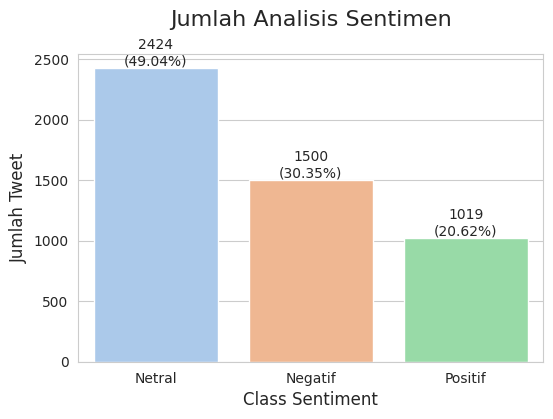

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sentiment_count = df['label'].value_counts()
sns.set_style("whitegrid")

fig, ax = plt.subplots(figsize=(6, 4))
ax = sns.barplot(x=sentiment_count.index, y=sentiment_count.values, palette="pastel")
plt.title("Jumlah Analisis Sentimen", fontsize=16, pad=20)
plt.xlabel("Class Sentiment", fontsize=12)
plt.ylabel("Jumlah Tweet", fontsize=12)

total = len(df['label'])

for i, count in enumerate(sentiment_count.values):
    percentage = f'{100 * count / total:.2f}%'
    ax.text(i, count + 0.10, f'{count}\n({percentage})', ha='center', va='bottom')

plt.show()

# Menyimpan data yang sudah diproses ke file baru
df.to_csv('labeling_data.csv', index=False)

In [27]:
label_count = df['label'].value_counts()
label_count

,count
label,
Netral,2424
Negatif,1500
Positif,1019


**WORLDCLOUD LABEL POSITIF**

In [28]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

# Daftar stopwords tambahan yang ingin dikecualikan
stopwords = set(STOPWORDS)
stopwords.update([
    'https', 'co', 'RT', '...', 'amp', 'lu', 'deh', 'fyp', 'ya', 'gue',
    'kak', 'tan', 'ajar', 'dan', 'di', 'ke', 'sih',
    'dari', 'adalah', 'yang', 'untuk', 'dengan', 'pada', 'ini' , 'yg'
])

# Fungsi untuk membuat word cloud
def generate_wordcloud(text, title):
    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white',
        stopwords=stopwords,
        max_words=100,
        colormap='tab20'
    ).generate(text)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=16, fontweight='bold')
    plt.show()

# Pisahkan dataset berdasarkan sentimen
sentimen_Neutral = df[df['label'] == 'Netral']['cleaned_komen'].str.cat(sep=' ')
sentimen_Negative = df[df['label'] == 'Negatif']['cleaned_komen'].str.cat(sep=' ')
sentimen_Positive = df[df['label'] == 'Positif']['cleaned_komen'].str.cat(sep=' ')

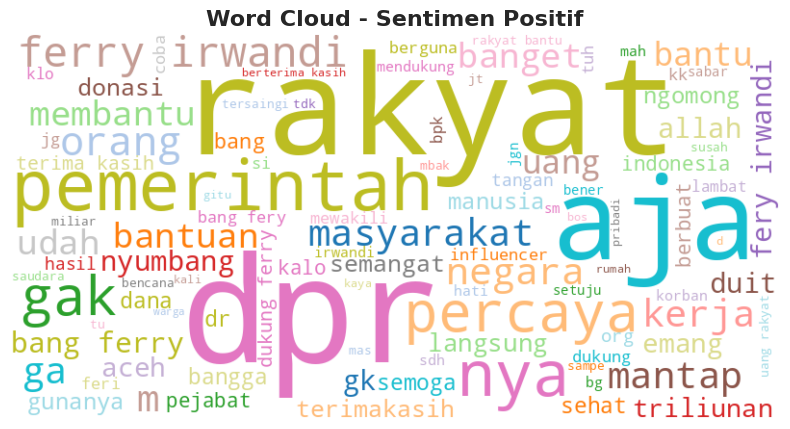

In [29]:
# Buat word cloud untuk masing-masing sentimen
generate_wordcloud(sentimen_Positive, "Word Cloud - Sentimen Positif")

**LABEL NEGATIVE**

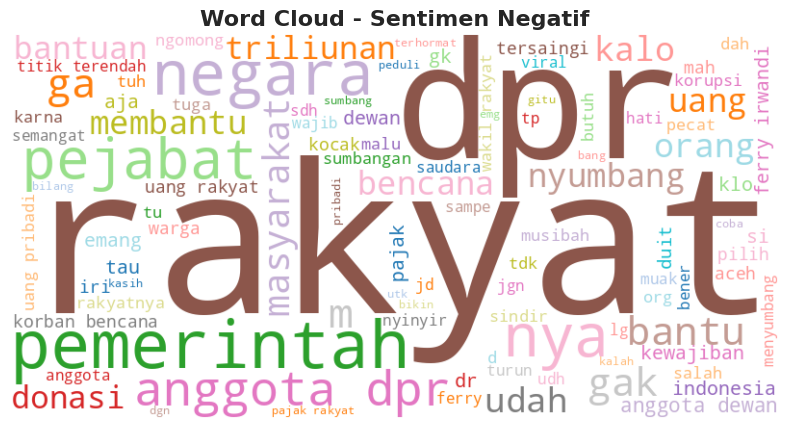

In [30]:
# Buat word cloud untuk masing-masing sentimen
generate_wordcloud(sentimen_Negative, "Word Cloud - Sentimen Negatif")

**LABEL NETRAL**

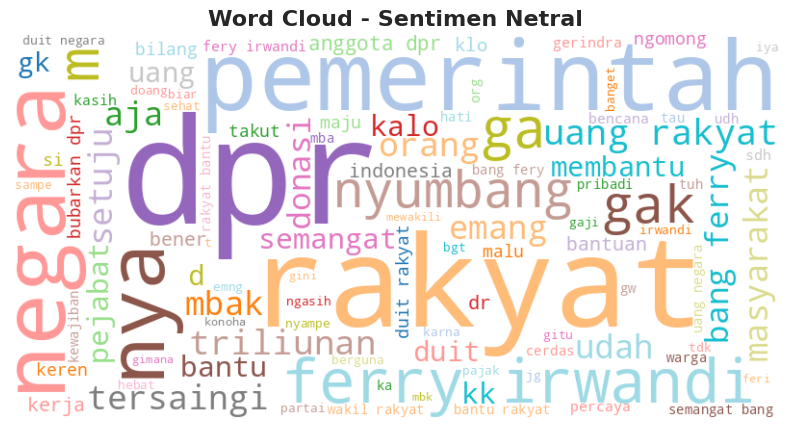

In [31]:
# Buat word cloud untuk masing-masing sentimen
generate_wordcloud(sentimen_Neutral, "Word Cloud - Sentimen Netral")

**FEATURE EXTRACTION**

In [32]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

# Isi nilai NaN dengan string kosong
df['stemmed_komen'] = df['stemmed_komen'].fillna('')

# Buat list dari kolom 'steming_data'
df_list = df['stemmed_komen'].tolist()

# Buat objek TfidfVectorizer
df_tfidf = TfidfVectorizer()

# Lakukan transformasi fitur
X = df_tfidf.fit_transform(df_list)

print('Feature Extraction Selesai!!!')
print('===== Bentuk Transformasi Feature Extraction =====')
print(X.shape)

# Dapatkan nama fitur (kata-kata unik)
feature_names = df_tfidf.get_feature_names_out()

# Hitung total skor TF-IDF untuk setiap term (kata)
tfidf_sums = X.sum(axis=0)

# Buat DataFrame untuk menampilkan hasil
tfidf_df = pd.DataFrame({
    'term': feature_names,
    'tfidf_sum': tfidf_sums.tolist()[0]
})

# Urutkan berdasarkan skor TF-IDF terbesar
tfidf_df = tfidf_df.sort_values('tfidf_sum', ascending=False)

print("\n==== Top 20 Terms by Total TF-IDF Score ====")
print(tfidf_df.head(20))

print("\n==== IDF Values ====")
idf_values = df_tfidf.idf_
idf_df = pd.DataFrame({
    'Term': feature_names,
    'IDF': idf_values
})
print(idf_df.head(20))

print("\n==== TF-IDF values for the first 5 documents ====")
for i in range(min(5, len(df_list))):
    first_document_tfidf = pd.DataFrame(
        X[i].T.todense(),
        index=feature_names,
        columns=["TF-IDF"]
    )
    print(f"\nDocument {i+1} TF-IDF Values:")
    print(first_document_tfidf.sort_values("TF-IDF", ascending=False).head(10))

Feature Extraction Selesai!!!
===== Bentuk Transformasi Feature Extraction =====
(4943, 5289)

==== Top 20 Terms by Total TF-IDF Score ====
          term   tfidf_sum
1216       dpr  217.341231
4002    rakyat  191.451302
5261        yg  132.050012
3810  perintah  111.828449
1418     ferry   99.222227
396      bantu   99.050293
3242    negara   95.372530
1906   irwandi   88.421025
3446       nya   81.113554
5039      uang   78.580518
358       bang   73.687281
4181     saing   70.486192
176    anggota   67.461288
1490       gak   61.358458
5220        ya   61.328542
1958     jabat   60.767200
70         aja   56.149823
4951   triliun   54.936590
3511  nyumbang   53.821093
1466        ga   52.274578

==== IDF Values ====
          Term       IDF
0        aaaik  8.812783
1     aamiiinn  8.812783
2       aamiin  7.203345
3       aappun  8.812783
4      abaekan  8.812783
5         abai  7.203345
6        abang  6.797880
7      abangda  8.812783
8          abg  8.407318
9         abis  7.896

In [33]:
y = df['label']
print(y)

0        Netral
1       Negatif
2        Netral
3       Positif
4        Netral
         ...   
4938    Negatif
4939     Netral
4940    Negatif
4941    Negatif
4942    Positif
Name: label, Length: 4943, dtype: object


In [34]:
print(X)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 27589 stored elements and shape (4943, 5289)>
  Coords	Values
  (0, 4334)	0.576205218514357
  (0, 358)	0.49964513614118095
  (0, 1418)	0.44858929695857075
  (0, 1906)	0.4659505625508977
  (1, 1906)	0.315854874162322
  (1, 4065)	0.7282326943838733
  (1, 1431)	0.38921616653766794
  (1, 4480)	0.4673581250005508
  (2, 1616)	0.7071067811865475
  (2, 2065)	0.7071067811865475
  (3, 1418)	0.38885093823343986
  (3, 1906)	0.40390021484406696
  (3, 1642)	0.5700849477056825
  (3, 1251)	0.5313615300739916
  (3, 1216)	0.2798528917855344
  (4, 3577)	0.7574731295788326
  (4, 3446)	0.652866340046758
  (5, 1216)	0.18680867364669596
  (5, 2710)	0.5080951557283959
  (5, 499)	0.32045108183263393
  (5, 2069)	0.43803514598837184
  (5, 2632)	0.5155268653450119
  (5, 2474)	0.38289711191713854
  (6, 1418)	0.40745143998903016
  (6, 1906)	0.42322059166872106
  :	:
  (4938, 2089)	0.47318227062287654
  (4939, 2474)	0.5474300840325276
  (4939, 5261)	0.302

**KLASIFIKASI MODEL MACHINE LEARNING**

In [35]:
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import seaborn as sns
import matplotlib.pyplot as plt

Jumlah data training (X_train): 3954
Jumlah data testing (X_test): 989


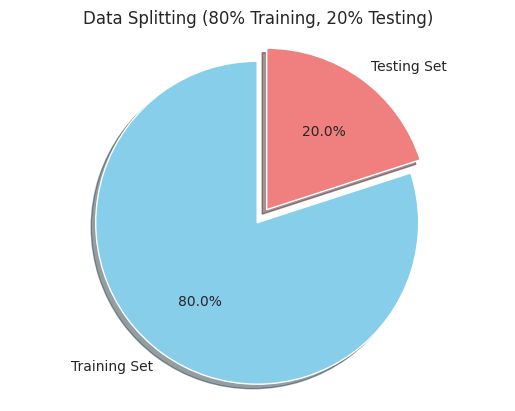

In [53]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Print the shapes of the resulting datasets
print("Jumlah data training (X_train):", X_train.shape[0])
print("Jumlah data testing (X_test):", X_test.shape[0])

# Visualize the data split
import matplotlib.pyplot as plt

train_size = X_train.shape[0]
test_size = X_test.shape[0]
total_size = train_size + test_size

labels = ['Training Set', 'Testing Set']
sizes = [train_size, test_size]
colors = ['skyblue', 'lightcoral']
explode = (0.1, 0)  # explode 1st slice

plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%', shadow=True, startangle=90)
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.title('Data Splitting (80% Training, 20% Testing)')
plt.show()

Sebelum cleaning: 4943
Setelah cleaning: 4478

Training: Logistic Regression
Accuracy: 0.7299
Classification Report:
              precision    recall  f1-score   support

     Negatif       0.79      0.70      0.74       300
      Netral       0.67      0.84      0.75       392
     Positif       0.84      0.55      0.67       204

    accuracy                           0.73       896
   macro avg       0.77      0.70      0.72       896
weighted avg       0.75      0.73      0.73       896



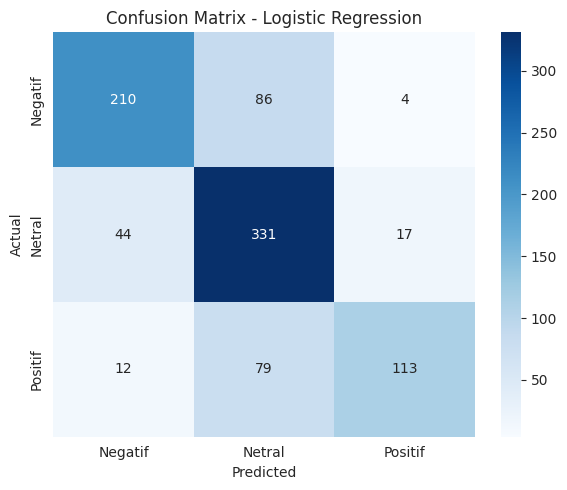


Training: Decision Tree
Accuracy: 0.6931
Classification Report:
              precision    recall  f1-score   support

     Negatif       0.69      0.69      0.69       300
      Netral       0.71      0.73      0.72       392
     Positif       0.66      0.62      0.64       204

    accuracy                           0.69       896
   macro avg       0.69      0.68      0.68       896
weighted avg       0.69      0.69      0.69       896



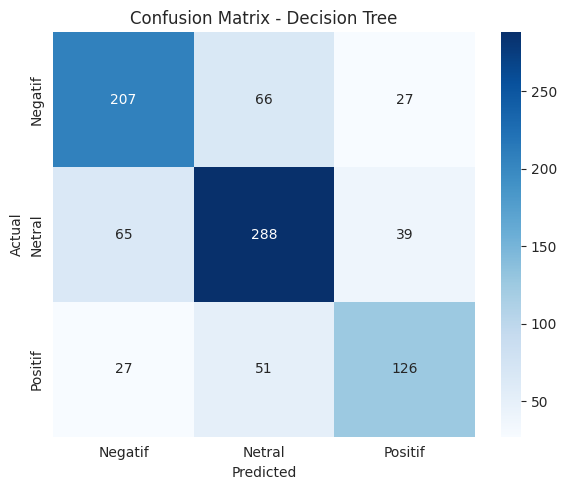


Training: Random Forest
Accuracy: 0.7087
Classification Report:
              precision    recall  f1-score   support

     Negatif       0.76      0.65      0.70       300
      Netral       0.65      0.82      0.73       392
     Positif       0.81      0.58      0.68       204

    accuracy                           0.71       896
   macro avg       0.74      0.68      0.70       896
weighted avg       0.72      0.71      0.71       896



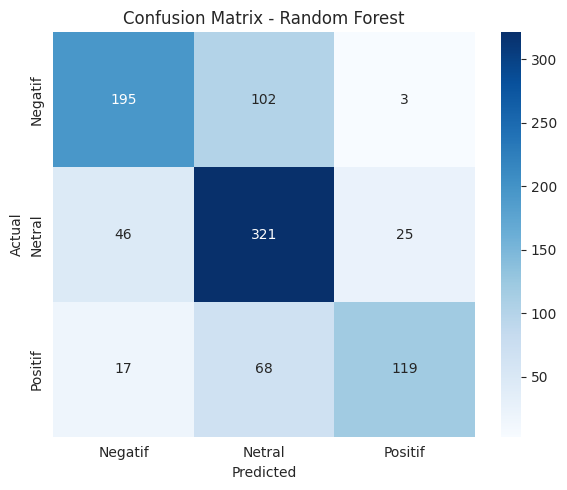


Training: SVM
Accuracy: 0.7511
Classification Report:
              precision    recall  f1-score   support

     Negatif       0.82      0.70      0.76       300
      Netral       0.69      0.85      0.76       392
     Positif       0.84      0.64      0.72       204

    accuracy                           0.75       896
   macro avg       0.78      0.73      0.75       896
weighted avg       0.77      0.75      0.75       896



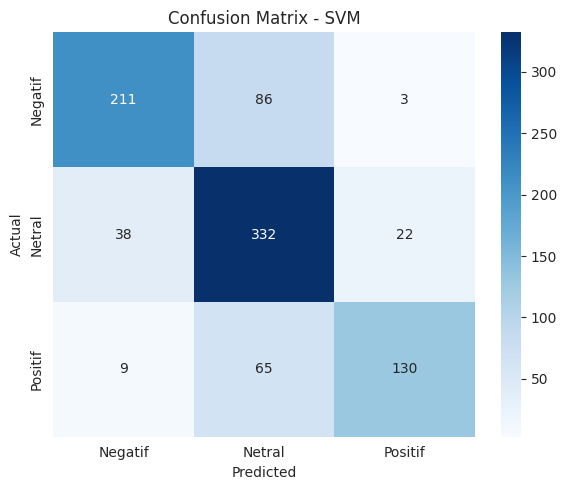


Training: KNN
Accuracy: 0.4911
Classification Report:
              precision    recall  f1-score   support

     Negatif       0.85      0.08      0.14       300
      Netral       0.46      0.99      0.63       392
     Positif       0.94      0.14      0.25       204

    accuracy                           0.49       896
   macro avg       0.75      0.40      0.34       896
weighted avg       0.70      0.49      0.38       896



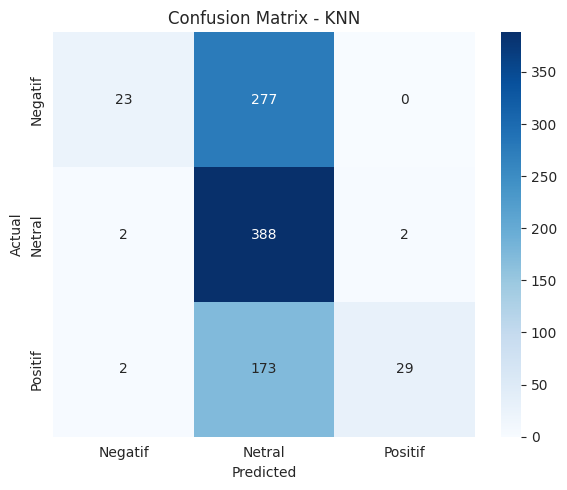


Training: Naive Bayes
Accuracy: 0.6741
Classification Report:
              precision    recall  f1-score   support

     Negatif       0.73      0.66      0.69       300
      Netral       0.61      0.85      0.71       392
     Positif       0.90      0.36      0.51       204

    accuracy                           0.67       896
   macro avg       0.75      0.62      0.64       896
weighted avg       0.72      0.67      0.66       896



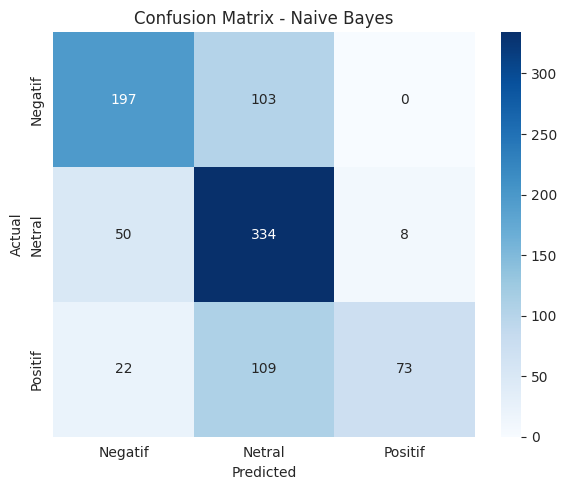


RINGKASAN MODEL
Logistic Regression  | Accuracy: 0.7299
Decision Tree        | Accuracy: 0.6931
Random Forest        | Accuracy: 0.7087
SVM                  | Accuracy: 0.7511
KNN                  | Accuracy: 0.4911
Naive Bayes          | Accuracy: 0.6741


In [54]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Baca data
df = pd.read_csv('labeling_data.csv')

# 2. HAPUS BARIS YANG TIDAK VALID
# Pastikan tidak ada NaN di 'cleaned_komen' atau 'label'
print("Sebelum cleaning:", len(df))
df = df.dropna(subset=['cleaned_komen', 'label'])  # Hapus jika salah satu NaN

# Hapus juga yang string kosong/spasi
df = df[df['cleaned_komen'].str.strip() != '']
print("Setelah cleaning:", len(df))

# 3. Siapkan fitur (X) dan target (y)
X = df['cleaned_komen']
y = df['label']

# 4. Ubah teks jadi vektor numerik
vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words='english',
    lowercase=True,
    ngram_range=(1, 2)  # opsional: tambah bigram
)
X_vec = vectorizer.fit_transform(X)

# 5. Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_vec, y, test_size=0.2, random_state=42, stratify=y  # stratify untuk distribusi seimbang
)

# 6. Definisikan classifier
classifiers = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(kernel='linear', random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Naive Bayes': MultinomialNB()
}

# 7. Train & evaluasi
results = {}
for name, clf in classifiers.items():
    print(f"\n{'='*50}")
    print(f"Training: {name}")
    print(f"{'='*50}")

    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    results[name] = {'accuracy': accuracy, 'report': report, 'cm': cm}

    print(f"Accuracy: {accuracy:.4f}")
    print("Classification Report:")
    print(report)

    # Plot confusion matrix
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=sorted(y_test.unique()),
                yticklabels=sorted(y_test.unique()))
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

# 8. Ringkasan
print("\n" + "="*60)
print("RINGKASAN MODEL")
print("="*60)
for name, res in results.items():
    print(f"{name:20} | Accuracy: {res['accuracy']:.4f}")

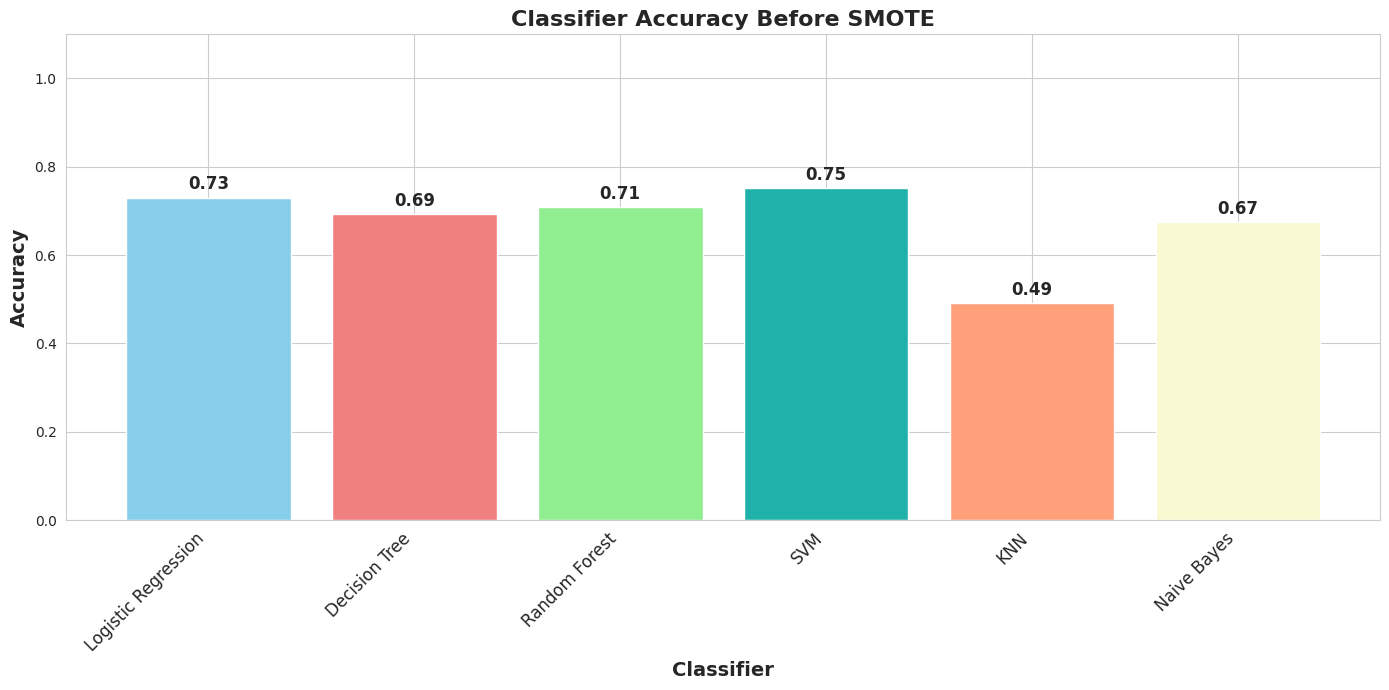

In [55]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Assuming 'results' dictionary is defined from previous code
classifiers = list(results.keys())
accuracy_before = [results[name]['accuracy'] for name in classifiers]

# Improved Plotting
plt.figure(figsize=(14, 7))  # Slightly larger figure for better readability
bars = plt.bar(classifiers, accuracy_before, color=['skyblue', 'lightcoral', 'lightgreen', 'lightseagreen', 'lightsalmon', 'lightgoldenrodyellow'])
plt.xlabel("Classifier", fontsize=14, fontweight='bold')
plt.ylabel("Accuracy", fontsize=14, fontweight='bold')
plt.title("Classifier Accuracy Before SMOTE", fontsize=16, fontweight='bold')
plt.ylim(0, 1.1)  # Set y-axis limit
plt.xticks(rotation=45, ha='right', fontsize=12)  # Adjust font size and rotation

# Annotate bars with accuracy values
for bar, acc in zip(bars, accuracy_before):
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{acc:.2f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()  # Ensure labels are not cut off
plt.show()